# ATMS 523 Module 6 Homework
_Megan Walker-Radtke_

## Instructions
### Datasets

Use the Storm Prediction Center tornado dataset https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv

Also, use the ENSO, PDO, NAO, and AO dataframe from earlier module.

### Assignment

1) Aggregate the tornado data over the following states into a monthly count of tornadoes:
   
   - Illinois
   
2. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

4. Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.

5. Perform a feature importance and multipass permutation analysis of your features.

6. Create a SHAP Summary Plot showing feature importance and feature effects.

7. Create a SHAP Feature Dependence for the ENSO index.

8. Any observations on the importance of the various features in your model from the XAI techniques you tried?


#### Import Libraries and Datasets

In [139]:
# Import libraries
import pandas as pd
import numpy as np




### Step 1: Aggregate the tornado data over the Illinois into a monthly count of tornadoes

In [140]:
# Import climate indices dataset (created in Module 4, saved as .csv, and imported here)
climate_indices = pd.read_csv('climate_indices.csv').iloc[:,:-1]  # Exclude the last column which is observed temp anomaly from Mod 4 (uncessary for this)
# Display the first few rows of the dataset
print(climate_indices.head())

# Import tornado dataset
tornado_data = pd.read_csv('1950-2021_actual_tornadoes.csv')
# Display the first few rows of the dataset
print(tornado_data.head())

   Unnamed: 0  ENSO   PDO   NAO     AO
0  1951-01-01   1.5 -1.19  0.08 -0.085
1  1951-02-01   0.9 -1.52  0.70 -0.400
2  1951-03-01  -0.1 -1.72 -1.02 -1.934
3  1951-04-01  -0.3 -1.35 -0.22 -0.776
4  1951-05-01  -0.7 -1.29 -0.59 -0.863
    om    yr  mo  dy        date      time  tz  st  stf  stn  ...   len  wid  \
0  192  1950  10   1  1950-10-01  21:00:00   3  OK   40   23  ...  15.8   10   
1  193  1950  10   9  1950-10-09  02:15:00   3  NC   37    9  ...   2.0  880   
2  195  1950  11  20  1950-11-20  02:20:00   3  KY   21    1  ...   0.1   10   
3  196  1950  11  20  1950-11-20  04:00:00   3  KY   21    2  ...   0.1   10   
4  197  1950  11  20  1950-11-20  07:30:00   3  MS   28   14  ...   2.0   37   

   ns  sn  sg   f1  f2  f3  f4  fc  
0   1   1   1   25   0   0   0   0  
1   1   1   1   47   0   0   0   0  
2   1   1   1  177   0   0   0   0  
3   1   1   1  209   0   0   0   0  
4   1   1   1  101   0   0   0   0  

[5 rows x 29 columns]


In [141]:
# Clean up climate_indices dataframe - need to rename and set date as index
climate_indices.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
climate_indices.set_index(pd.to_datetime(climate_indices['date']), inplace=True)
climate_indices.drop(columns=['date'], inplace=True)
climate_indices.head()


,ENSO,PDO,NAO,AO
date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863


In [142]:
# Check the data type of the 'date' column
type(tornado_data['date'].iat[0])
# stored as a string, so need to convert it to a datetime object in order to use datetime functions for aggregation
tornado_data['date'] = pd.to_datetime(tornado_data['date'], errors='coerce')
# check parse failures
print("Check NaNs:", tornado_data['date'].isna().sum())
# verify dtype
print("Date dtype:", tornado_data['date'].dtype)
# 'date' converted to datetime with no errors resulting in NaNs



Check NaNs: 0
Date dtype: datetime64[ns]


In [143]:
# Take only the subset of tornadoes from Illinois
tornado_IL = tornado_data[tornado_data['st'] == 'IL'].copy()
tornado_IL.set_index('date', inplace=True)
tornado_IL.head(20)

,om,yr,mo,dy,time,tz,st,stf,stn,mag,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
date,,,,,,,,,,,,,,,,,,,,,
1950-12-02,198,1950,12,2,15:00:00,3,IL,17,7,2,...,18.8,50,1,1,1,119,117,0,0,0
1950-12-02,199,1950,12,2,16:00:00,3,IL,17,8,3,...,18.0,200,1,1,1,119,5,0,0,0
1950-12-02,201,1950,12,2,17:30:00,3,IL,17,9,1,...,9.6,50,1,1,1,157,0,0,0,0
1950-01-25,6,1950,1,25,21:00:00,3,IL,17,3,2,...,0.1,100,1,1,1,91,0,0,0,0
1950-01-03,2,1950,1,3,11:55:00,3,IL,17,2,3,...,3.6,130,1,1,1,135,0,0,0,0
1950-03-27,48,1950,3,27,16:30:00,3,IL,17,4,2,...,3.0,50,1,1,1,113,0,0,0,0
1950-06-13,135,1950,6,13,03:00:00,3,IL,17,5,1,...,0.1,10,1,1,1,15,0,0,0,0
1950-07-16,165,1950,7,16,22:15:00,3,IL,17,6,1,...,1.0,33,1,1,1,105,0,0,0,0
1951-11-13,241,1951,11,13,13:15:00,3,IL,17,3,2,...,47.4,50,1,1,1,125,179,113,0,0


In [144]:
# Aggregate to monthly counts and manually check for accuracy over the first 12 months
tornado_IL_monthly = tornado_IL.resample('M').size()
tornado_IL_monthly.head(12)
# Looks good!

/var/folders/jc/711xkp256bz0pq8mq4dcp94h0000gn/T/ipykernel_25574/3785086535.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tornado_IL_monthly = tornado_IL.resample('M').size()


date
1950-01-31    2
1950-02-28    0
1950-03-31    1
1950-04-30    0
1950-05-31    0
1950-06-30    1
1950-07-31    1
1950-08-31    0
1950-09-30    0
1950-10-31    0
1950-11-30    0
1950-12-31    3
Freq: ME, dtype: int64

In [145]:
# The climate indices dataset is monthly, but the index is set to the first day of the month,
# whereas the tornado_IL_monthly index is set to the last day of the month.
# So, we need to adjust the tornado data index to match the climate indices index for merging
tornado_IL_monthly.index = tornado_IL_monthly.index - pd.offsets.MonthBegin(1)  # Set to first day of month
tornado_IL_monthly.head(12)

date
1950-01-01    2
1950-02-01    0
1950-03-01    1
1950-04-01    0
1950-05-01    0
1950-06-01    1
1950-07-01    1
1950-08-01    0
1950-09-01    0
1950-10-01    0
1950-11-01    0
1950-12-01    3
dtype: int64

### Step 2: Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [146]:
# the tornado and climate indices datasets now have aligned monthly indices and can be merged for analysis
# Combine the two datasets into a single DataFrame for analysis
combined_data = pd.merge(climate_indices, tornado_IL_monthly.rename('IL_tornado_count'), left_index=True, right_index=True, how='inner')
combined_data.head(-10)

,ENSO,PDO,NAO,AO,IL_tornado_count
date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0
1951-02-01,0.9,-1.52,0.70,-0.400,0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0
...,...,...,...,...,...
2020-10-01,0.5,-0.62,-0.65,-0.072,0
2020-11-01,0.7,-1.58,2.54,2.086,8
2020-12-01,1.8,-0.99,-0.30,-1.736,0


### Step 3: Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes.  Create a scatter plot of the predicted and observed number of tornadoes over these states.  Report the correlation coefficient and RMSE of your model.

In [147]:
# Import libraries for modeling
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, VBox, HBox, fixed, Output
from IPython.display import display, HTML

In [148]:
# Set variables for modeling
df = combined_data.copy(deep=True)
target_col = 'IL_tornado_count'
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()
feature_names = X.columns.tolist()
X.shape, y.shape

((852, 4), (852,))

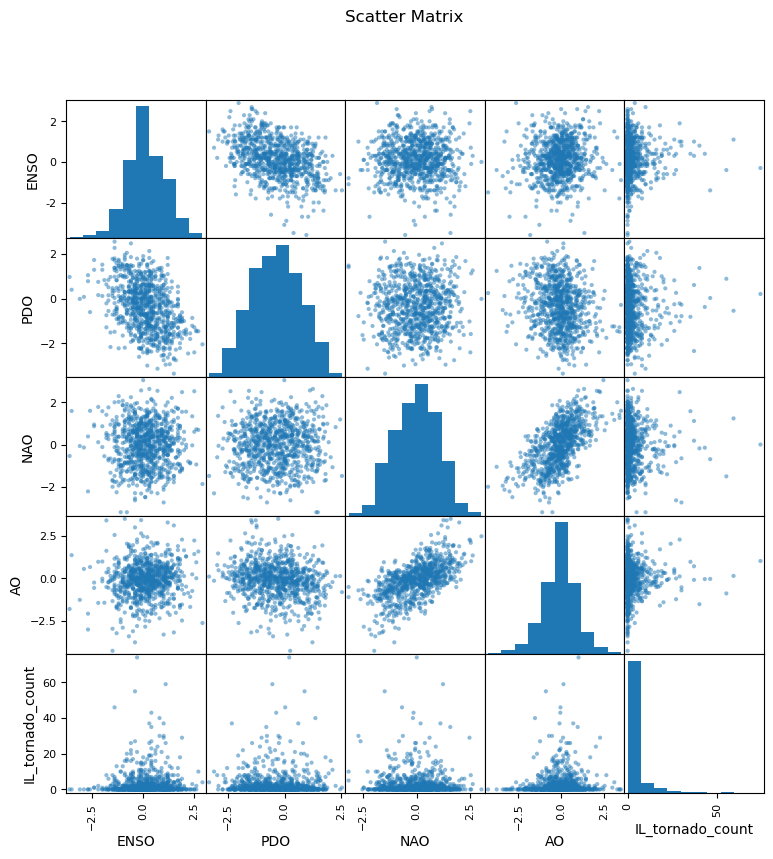

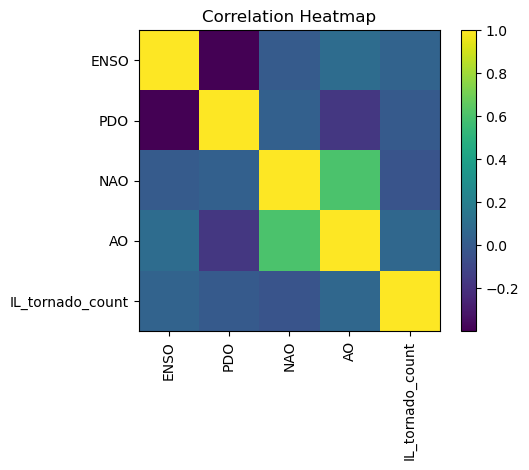

In [149]:
# EDA visualization 
sample = X.copy()
sample[target_col] = y

scatter_matrix(sample, figsize=(9,9), diagonal='hist')
plt.suptitle('Scatter Matrix')
plt.show()

corr = df.corr(numeric_only=True)
fig, ax = plt.subplots()
im = ax.imshow(corr.values, interpolation='nearest')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
ax.set_title('Correlation Heatmap')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# There appear to be some correlations between some of the individual climate indices and tornado counts, but the data are NOISY, and the correlation coefficients are low.

In [150]:
# Split the training and testing data
# reserving 25% of the data for testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (639, 4) Test size: (213, 4)


RMSE: 2.81
RMSE as fraction of observed std dev: 0.36
Correlation Coefficient: 0.07


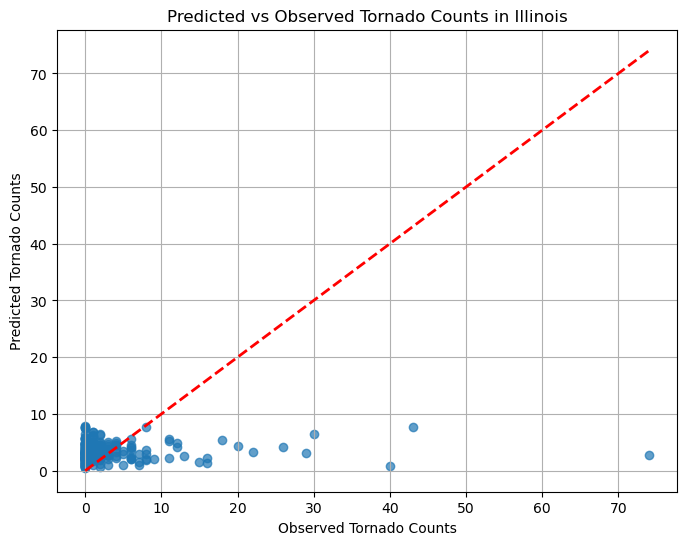

In [151]:
# Fit the random forest regression model
forest = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, max_depth=10, random_state=42)
forest.fit(X_train, y_train)

# Use the model to make predictions on the test set
y_pred = forest.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')
# RMSE as a fraction of the standard deviation of the observed values
rmse_frac = rmse / np.std(y_test)
print(f'RMSE as fraction of observed std dev: {rmse_frac:.2f}')
corr_coef = np.corrcoef(y_test, y_pred)[0, 1]
print(f'Correlation Coefficient: {corr_coef:.2f}')

# Plot predicted vs observed tornado counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Tornado Counts')
plt.ylabel('Predicted Tornado Counts')
plt.title('Predicted vs Observed Tornado Counts in Illinois')
plt.grid()
plt.show()

# Just about as terrible as you can get: all scatter, no skill.  
# The climate indices alone do not appear to provide useful predictive information for monthly tornado counts in Illinois.




#### Try tuning the model hyperparameters

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=3, min_samples_split=9, n_estimators=472; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=3, min_samples_split=9, n_estimators=472; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=3, min_samples_split=9, n_estimators=472; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=3, min_samples_split=9, n_estimators=472; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=0.3, min_samples_leaf=3, min_samples_split=9, n_estimators=472; total time=   0.4s
[CV] END bootstrap=True, max_depth=30, max_features=None, min_samples_leaf=3, min_samples_split=9, n_estimators=800; total time=   1.1s
[CV] END bootstrap=True, max_depth=30, max_features=None, min_samples_leaf=3, min_samples_split=9, n_estimators=800; total time

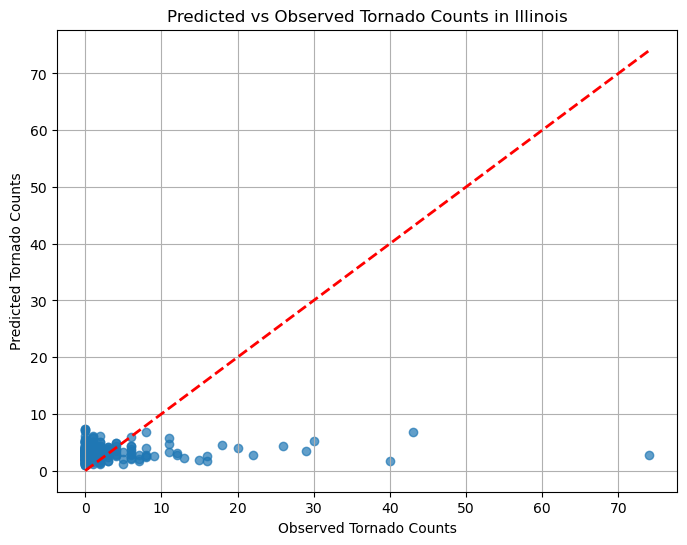

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(100, 1001),     # sample an int between 100 and 1000
    'max_depth': [None, 10, 20, 30, 40],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, None],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}

rand = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,         # number of sampled parameter settings
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42,
    refit=True
)

rand.fit(X_train, y_train)

print("best params:", rand.best_params_)
print("best CV score (neg RMSE):", rand.best_score_)

best_model = rand.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')
# RMSE as a fraction of the standard deviation of the observed values
rmse_frac = rmse / np.std(y_test)
print(f'RMSE as fraction of observed std dev: {rmse_frac:.2f}')
corr_coef = np.corrcoef(y_test, y_pred)[0, 1]
print(f'Correlation Coefficient: {corr_coef:.2f}')

# Plot predicted vs observed tornado counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Tornado Counts')
plt.ylabel('Predicted Tornado Counts')
plt.title('Predicted vs Observed Tornado Counts in Illinois')
plt.grid()
plt.show()

# The tuned model is WORSE??? Correlation coefficient actually went down.

### Step 4: Create a one-hot encoding for the month of the year.  Repeat the scatterplot and compare the RMSE and correlation coefficient values.


In [153]:
df

,ENSO,PDO,NAO,AO,IL_tornado_count
date,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0
1951-02-01,0.9,-1.52,0.70,-0.400,0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0
...,...,...,...,...,...
2021-08-01,0.6,-0.95,-0.28,-0.209,16
2021-09-01,0.8,-1.96,-0.21,-0.252,0
2021-10-01,0.7,-3.13,-2.29,-0.146,10


In [154]:
# Import additional libraries for one-hot encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [155]:
# create month column 
df['month'] = df.index.month

# add one-hot encoding for month
month_dummies = pd.get_dummies(df['month'], prefix='month')
df = df.join(month_dummies)
df.head(20)

,ENSO,PDO,NAO,AO,IL_tornado_count,month,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0,1,True,False,False,False,False,False,False,False,False,False,False,False
1951-02-01,0.9,-1.52,0.70,-0.400,0,2,False,True,False,False,False,False,False,False,False,False,False,False
1951-03-01,-0.1,-1.72,-1.02,-1.934,0,3,False,False,True,False,False,False,False,False,False,False,False,False
1951-04-01,-0.3,-1.35,-0.22,-0.776,0,4,False,False,False,True,False,False,False,False,False,False,False,False
1951-05-01,-0.7,-1.29,-0.59,-0.863,0,5,False,False,False,False,True,False,False,False,False,False,False,False
1951-06-01,0.2,-1.77,-1.64,-0.918,2,6,False,False,False,False,False,True,False,False,False,False,False,False
1951-07-01,-1.0,-0.23,1.37,0.090,0,7,False,False,False,False,False,False,True,False,False,False,False,False
1951-08-01,-0.2,-1.76,-0.22,-0.377,0,8,False,False,False,False,False,False,False,True,False,False,False,False
1951-09-01,-1.1,-0.78,-1.36,-0.818,0,9,False,False,False,False,False,False,False,False,True,False,False,False


In [156]:
# I was getting errors related to booleans when using Shap, so preemptively replacing them with integers
df_int = df.replace({True: 1, False: 0})
df_int.head()

/var/folders/jc/711xkp256bz0pq8mq4dcp94h0000gn/T/ipykernel_25574/2443842269.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_int = df.replace({True: 1, False: 0})


,ENSO,PDO,NAO,AO,IL_tornado_count,month,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,
1951-01-01,1.5,-1.19,0.08,-0.085,0,1,1,0,0,0,0,0,0,0,0,0,0,0
1951-02-01,0.9,-1.52,0.70,-0.400,0,2,0,1,0,0,0,0,0,0,0,0,0,0
1951-03-01,-0.1,-1.72,-1.02,-1.934,0,3,0,0,1,0,0,0,0,0,0,0,0,0
1951-04-01,-0.3,-1.35,-0.22,-0.776,0,4,0,0,0,1,0,0,0,0,0,0,0,0
1951-05-01,-0.7,-1.29,-0.59,-0.863,0,5,0,0,0,0,1,0,0,0,0,0,0,0


In [158]:
df_int.drop(columns=['month'], inplace=True)  # drop original month column so it doesn't get treated as a numeric feature

RMSE: 2.85
RMSE as fraction of observed std dev: 0.34
Correlation Coefficient: 0.28


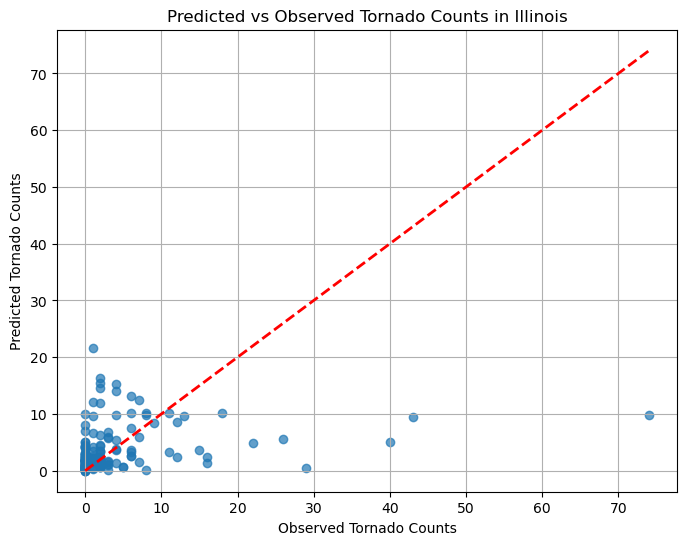

In [ ]:
# Try random forest model again, this time with one-hot encoded month features included, skipping the tuned hyperparameters
# since those didn't improve performance
X = df_int.drop(columns=['IL_tornado_count'])
y = df_int['IL_tornado_count']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the random forest regression model
forest = RandomForestRegressor(random_state=42)
forest.fit(X_train, y_train)

# Use the model to make predictions on the test set
y_pred = forest.predict(X_test)

# Evaluate model performance
rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse:.2f}')
# RMSE as a fraction of the standard deviation of the observed values
rmse_frac = rmse / np.std(y_test)
print(f'RMSE as fraction of observed std dev: {rmse_frac:.2f}')
corr_coef = np.corrcoef(y_test, y_pred)[0, 1]
print(f'Correlation Coefficient: {corr_coef:.2f}')

# Plot predicted vs observed tornado counts
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Tornado Counts')
plt.ylabel('Predicted Tornado Counts')
plt.title('Predicted vs Observed Tornado Counts in Illinois')
plt.grid()
plt.show()

# Still terrible! Although the correlation coefficient improved a bit, RMSE is higher.

In [161]:
# Checking train and test accuracy
print(f"RF train accuracy: {forest.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {forest.score(X_test, y_test):.3f}")

# training accuracy is good, but test accuracy is poor, indicating overfitting (?) of the training data
# Can't figure out how to fix that, so proceeding with a terrible model to step #5

RF train accuracy: 0.851
RF test accuracy: 0.041


### Step 5: Perform a feature importance and multipass permutation analysis of your features.

In [162]:
X_train.head()

,ENSO,PDO,NAO,AO,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,
2016-06-01,0.6,0.87,-0.43,0.313,0,0,0,0,0,1,0,0,0,0,0,0
1959-06-01,-0.1,0.23,0.40,-0.033,0,0,0,0,0,1,0,0,0,0,0,0
2016-08-01,0.7,-0.63,-1.65,0.472,0,0,0,0,0,0,0,1,0,0,0,0
1995-03-01,0.8,0.46,1.25,0.393,0,0,1,0,0,0,0,0,0,0,0,0
1986-11-01,-1.2,1.68,2.29,0.926,0,0,0,0,0,0,0,0,0,0,1,0


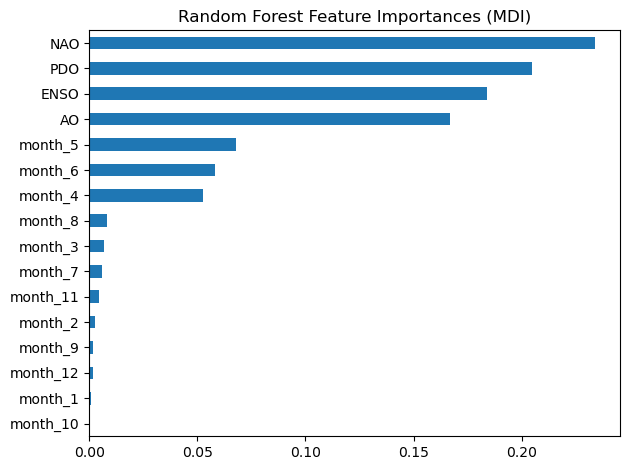

In [164]:
# Feature importance using Mean Decrease in Impurity (MDI)

feature_names = X_train.columns          

mdi_importances = pd.Series(
    forest.feature_importances_, index=feature_names
).sort_values(ascending=True)

ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

#NAO appears to be the most important feature according to MDI, followed by PDO, ENSO, and AO

In [165]:
# Permutation Importance Analysis

from sklearn.inspection import permutation_importance

train_result = permutation_importance(
    forest, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)
test_results = permutation_importance(
    forest, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_importances_idx = train_result.importances_mean.argsort()

In [166]:
train_importances = pd.DataFrame(
    train_result.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)
test_importances = pd.DataFrame(
    test_results.importances[sorted_importances_idx].T,
    columns=X.columns[sorted_importances_idx],
)

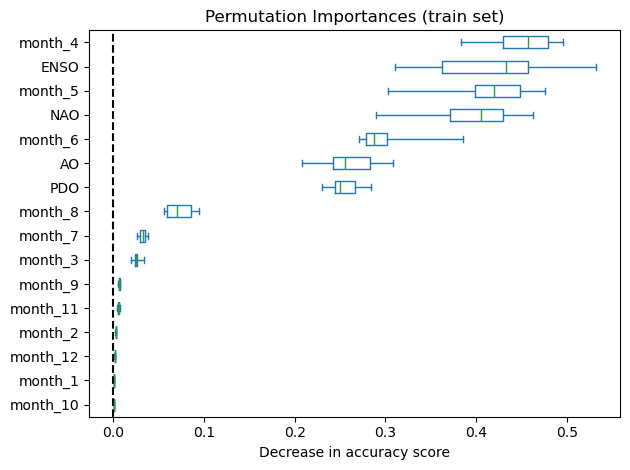

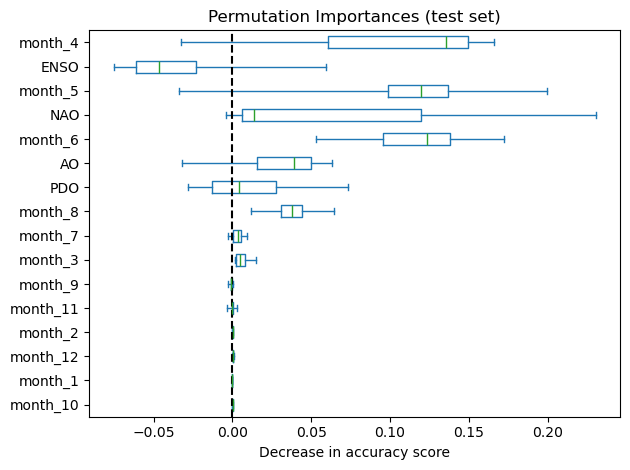

In [168]:
for name, importances in zip(["train", "test"], [train_importances, test_importances]):
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title(f"Permutation Importances ({name} set)")
    ax.set_xlabel("Decrease in accuracy score")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.figure.tight_layout()

    # ENSO quite important for training set, but minimally important for test set
    # NAO also important for training set, less so for test set
    # Why??
    # Tornado counts are most predictable by month - specifically the month of April. Climatologically max tornadoes in April. Not very useful.

### Step 6: Create a SHAP Summary Plot showing feature importance and feature effects.

In [172]:
import shap
shap.initjs()

# If `forest` is the trained RandomForestRegressor (not a pipeline)
explainer = shap.Explainer(forest, X_train_arr, feature_names=X_train_num.columns)
shap_values = explainer(X_test_arr, check_additivity=False)

In [173]:
shap_values

.values =
array([[ 4.42326643e-01, -1.25070014e-01, -3.93666647e-01, ...,
        -1.17000008e-03, -1.64433334e-02, -7.36499985e-03],
       [ 1.00991002e+00, -2.09999990e-01,  3.66916661e-01, ...,
        -8.07500015e-03, -3.11133333e-02, -1.31150002e-02],
       [-1.49716671e-01,  2.86816640e-01, -7.30650067e-02, ...,
        -1.73500024e-03, -1.50466669e-02, -5.85833328e-03],
       ...,
       [ 8.69450035e-02,  1.32603328e-01,  1.10325838e+00, ...,
        -9.23333334e-04, -2.25033335e-02, -9.77166663e-03],
       [ 8.33781679e-01,  3.24568293e-01, -2.54876711e-01, ...,
        -5.09500017e-03, -1.54316667e-02, -4.27333336e-03],
       [ 1.17306670e-01, -1.44667173e-03,  6.84440023e-01, ...,
        -7.66166680e-03, -7.77433329e-02,  2.86116667e-02]],
      shape=(171, 16))

.base_values =
array([2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273,
       2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.6273,
       2.6273, 2.6273, 2.6273, 2.6273, 2.6273, 2.627

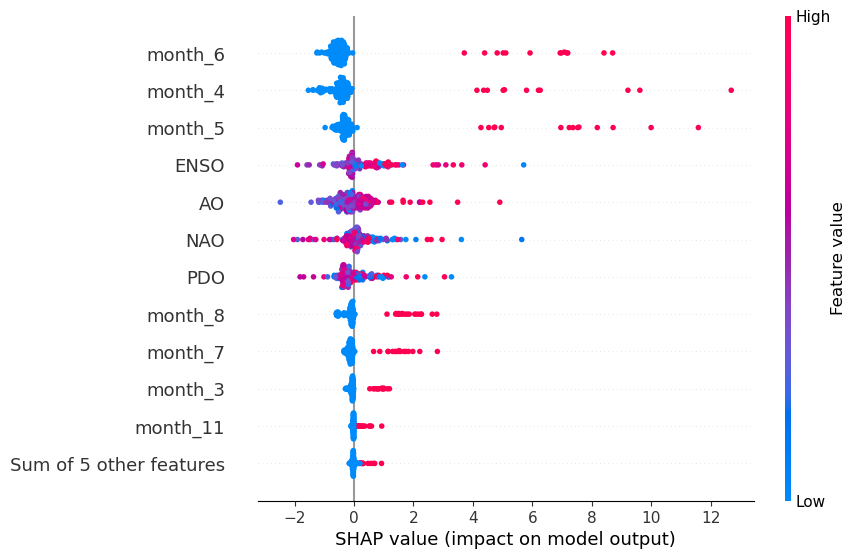

In [174]:
shap.plots.beeswarm(shap_values, max_display=12)

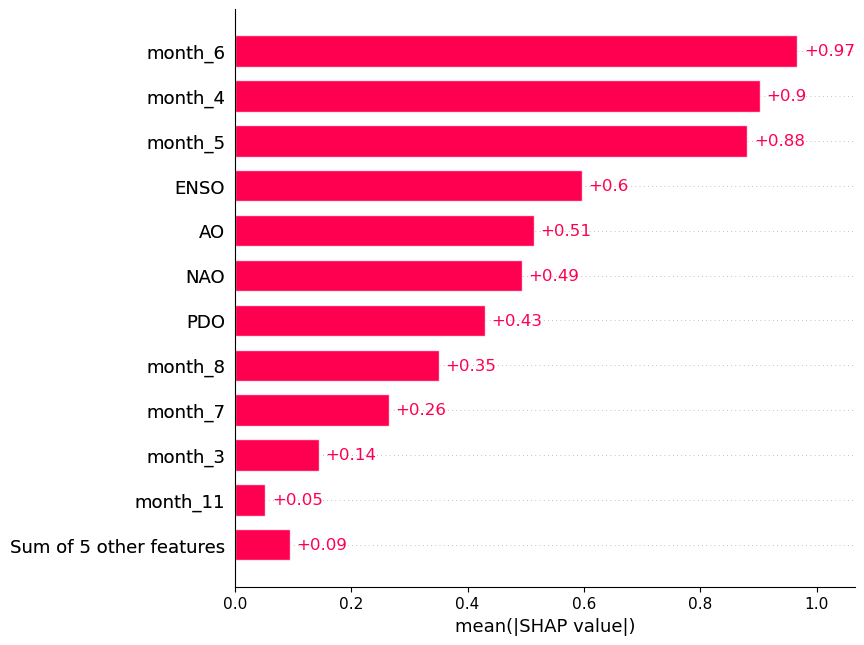

In [175]:
shap.plots.bar(shap_values, max_display=12)

The month matters for prediction when it's the climatological tornado season (April, May, June) in Illinois - i.e. when the tornado count values are high within those months. Otherwise, it's not very impactful (not important for low values of monthly tornado counts, per beeswarm).

### Step 7: Create a SHAP Feature Dependence for the ENSO index.

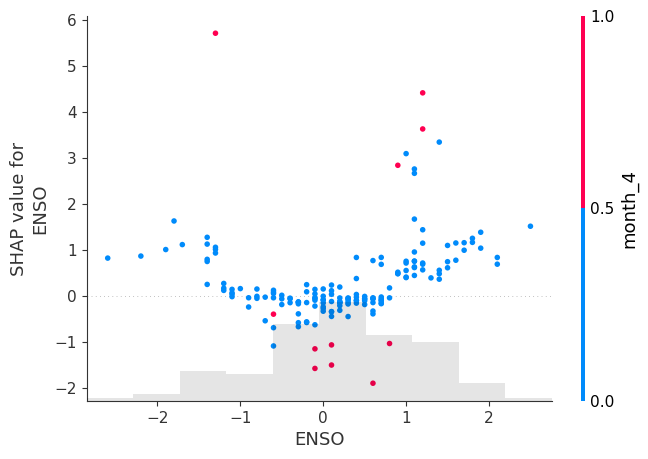

In [176]:
# ENSO dependence colored by strongest interaction automatically
shap.plots.scatter(shap_values[:, "ENSO"], color=shap_values)

### Step 8: Any observations on the importance of the various features in your model from the XAI techniques you tried?

#### Answer
The data are VERY noisy, and correlations are quite weak. I'm not sure whether this is a result of a lack of a strong relationship between the examined climate modes and tornadoes in general, or whether it's a result of not using a diverse dataset (just focusing on IL tornadoes). Perhaps the relationship is weak in IL but stronger in other states, other regions that tend to be more influenced by ENSO? That would require examining differences in models trained on different states' tornado data as well as models trained on _all_ states' tornado data.

For the random forest features importances based on mean decrease in impurity, the climatological modes were the most important, but when looking at permutation importance and Shapley values, the month of the year was the most significant feature. I suspect this is due to the fact that April, May, and June are the climatological peak of tornado season in IL. If there is a climate mode signal, it would show up more clearly in months with lots of tornadoes (if IL normally sees 0 tornadoes in November, it doesn't matter if its an El Nino year or not, on average, there will continue to be 0 tornadoes regardless of ENSO state).

I also wonder whether I'm seeing overfitting of the model - there are massive differences between the accurancy of the testing vs the training dataset:
RF train accuracy: 0.851
RF test accuracy: 0.041

Finally, using a grid search to tune the hyperparameters of the Random Forest Regression actually decreased my model performance, so I'm not sure what to make of that.